### Homework: going neural (6 pts)

We've checked out statistical approaches to language models in the last notebook. Now let's go find out what deep learning has to offer.

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/expanding_mind_lm_kn_3.png' width=300px>

We're gonna use the same dataset as before, except this time we build a language model that's character-level, not word level. Before you go:
* If you haven't done seminar already, use `seminar.ipynb` to download the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Working on character level means that we don't need to deal with large vocabulary or missing words. Heck, we can even keep uppercase words in text! The downside, however, is that all our sequences just got a lot longer.

However, we still need special tokens:
* Begin Of Sequence  (__BOS__) - this token is at the start of each sequence. We use it so that we always have non-empty input to our neural network. $P(x_t) = P(x_1 | BOS)$
* End Of Sequence (__EOS__) - you guess it... this token is at the end of each sequence. The catch is that it should __not__ occur anywhere else except at the very end. If our model produces this token, the sequence is over.


In [2]:
BOS, EOS = ' ', '\n'

import io, unicodedata

with io.open("./arxivData.json", "r", encoding="utf-8") as f:
    data = pd.read_json(f)

def normalize_line(text):
    text = unicodedata.normalize("NFC", text)
    return text

lines = data.apply(lambda row: (normalize_line(row['title']) + ' ; ' + normalize_line(row['summary']))[:512], axis=1) \
            .apply(lambda line: BOS + line.replace(EOS, ' ') + EOS) \
            .tolist()

# if you missed the seminar, download data here - https://yadi.sk/d/_nGyU2IajjR9-w

Our next step is __building char-level vocabulary__. Put simply, you need to assemble a list of all unique tokens in the dataset.

In [3]:
# get all unique characters from lines (including capital letters and symbols)
import unicodedata

def is_allowed_char(ch):
    if ch in (BOS, EOS):
        return True
    if not ch.isprintable():
        return False
    cat = unicodedata.category(ch)
    if cat.startswith('C'):
        return False
    return True

tokens = set(ch for line in lines for ch in line if is_allowed_char(ch))

tokens = sorted(tokens)
n_tokens = len(tokens)
print ('n_tokens = ',n_tokens)
assert 100 < n_tokens < 150
assert BOS in tokens, EOS in tokens

n_tokens =  135


We can now assign each character with its index in tokens list. This way we can encode a string into a torch-friendly integer vector.

In [4]:
# dictionary of character -> its identifier (index in tokens list)
token_to_id = {token: idx for idx, token in enumerate(tokens)}

In [5]:
assert len(tokens) == len(token_to_id), "dictionaries must have same size"
for i in range(n_tokens):
    assert token_to_id[tokens[i]] == i, "token identifier must be it's position in tokens list"

print("Seems alright!")

Seems alright!


Our final step is to assemble several strings in a integer matrix with shape `[batch_size, text_length]`. 

The only problem is that each sequence has a different length. We can work around that by padding short sequences with extra `"EOS"` tokens or cropping long sequences. Here's how it works:

In [6]:
def to_matrix(lines, max_len=None, pad=token_to_id[EOS], dtype=np.int64):
    """Casts a list of lines into torch-digestable matrix."""
    max_len = max_len or max(map(len, lines))
    lines_ix = np.full([len(lines), max_len], pad, dtype=dtype)
    bos_ix = token_to_id[BOS]
    for i in range(len(lines)):
        # map unknown characters to BOS (space) to avoid None
        line_ix = [token_to_id.get(ch, bos_ix) for ch in lines[i][:max_len]]
        lines_ix[i, :len(line_ix)] = line_ix
    return lines_ix

In [7]:
#Example: cast 4 random names to a single matrix, pad with zeros where needed.
dummy_lines = [
    ' abc\n',
    ' abacaba\n',
    ' abc1234567890\n',
]
print(to_matrix(dummy_lines))



[[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]


### Neural Language Model (2 points including training)

Just like for N-gram LMs, we want to estimate probability of text as a joint probability of tokens (symbols this time).

$$P(X) = \prod_t P(x_t \mid x_0, \dots, x_{t-1}).$$ 

Instead of counting all possible statistics, we want to train a neural network with parameters $\theta$ that estimates the conditional probabilities:

$$ P(x_t \mid x_0, \dots, x_{t-1}) \approx p(x_t \mid x_0, \dots, x_{t-1}, \theta) $$


But before we optimize, we need to define our neural network. Let's start with a fixed-window (aka convolutional) architecture:

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/fixed_window_lm.jpg' width=400px>


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [9]:
class FixedWindowLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=64):
        """ 
        A fixed window model that looks on at least 5 previous symbols.
        
        Note: fixed window LM is effectively performing a convolution over a sequence of words.
        This convolution only looks on current and previous words.
        Such convolution can be represented as a sequence of 2 operations:
        - pad input vectors by {strides * (filter_size - 1)} zero vectors on the "left", do not pad right
        - perform regular convolution with {filter_size} and {strides}
        
        - If you're absolutely lost, here's a hint: use nn.ZeroPad2d((NUM_LEADING_ZEROS, 0, 0, 0))
          followed by a nn.Conv1d(..., padding=0). And yes, its okay that padding is technically "2d".
        """
        super().__init__() # initialize base class to track sub-layers, trainable variables, etc.
        
        # embedding for input tokens
        self.emb = nn.Embedding(num_embeddings=n_tokens, embedding_dim=emb_size)
        
        # causal conv over sequence length (left pad only), kernel size = 5
        self.kernel_size = 5
        self.left_pad = self.kernel_size - 1
        self.conv = nn.Conv1d(in_channels=emb_size, out_channels=hid_size, kernel_size=self.kernel_size, padding=0, stride=1)
        
        # projection to vocabulary size
        self.proj = nn.Linear(hid_size, n_tokens)
        
    def __call__(self, input_ix):
        """
        compute language model logits given input tokens
        :param input_ix: batch of sequences with token indices, tensor: int32[batch_size, sequence_length]
        :returns: pre-softmax linear outputs of language model [batch_size, sequence_length, n_tokens]
            these outputs will be used as logits to compute P(x_t | x_0, ..., x_{t - 1})
            
        :note: that convolutions operate with tensors of shape [batch, channels, length], while linear layers
         and *embeddings* use [batch, length, channels] tensors. Use tensor.permute(...) to adjust shapes.

        """
        # embeddings: [B, T, E]
        x = self.emb(input_ix)
        # to conv1d: [B, E, T]
        x = x.permute(0, 2, 1)
        # left-pad time dimension to avoid lookahead: [B, E, T + left_pad]
        x = nn.functional.pad(x, (self.left_pad, 0))
        # conv over sequence: [B, H, T]
        x = self.conv(x)
        # back to [B, T, H]
        x = x.permute(0, 2, 1)
        # project to logits: [B, T, V]
        logits = self.proj(x)
        return logits
    
    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64)
        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens]
        return dict(zip(tokens, probs))
        

In [10]:
dummy_model = FixedWindowLanguageModel()

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = dummy_model(dummy_input_ix)

print('Weights:', tuple(name for name, w in dummy_model.named_parameters()))

Weights: ('emb.weight', 'conv.weight', 'conv.bias', 'proj.weight', 'proj.bias')


In [11]:
assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert np.all(np.isfinite(dummy_logits.data.cpu().numpy())), "inf/nan encountered"
assert not np.allclose(dummy_logits.data.cpu().numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"

In [12]:
# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = dummy_model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

We can now tune our network's parameters to minimize categorical crossentropy over training dataset $D$:

$$ L = {\frac1{|D|}} \sum_{X \in D} \sum_{x_i \in X} - \log p(x_t \mid x_1, \dots, x_{t-1}, \theta) $$

As usual with with neural nets, this optimization is performed via stochastic gradient descent with backprop.  One can also note that minimizing crossentropy is equivalent to minimizing model __perplexity__, KL-divergence or maximizng log-likelihood.

In [13]:
def compute_mask(input_ix, eos_ix=token_to_id[EOS]):
    """ compute a boolean mask that equals "1" until first EOS (including that EOS) """
    return F.pad(torch.cumsum(input_ix == eos_ix, dim=-1)[..., :-1] < 1, pad=(1, 0, 0, 0), value=True)

print('matrix:\n', dummy_input_ix.numpy())
print('mask:', compute_mask(dummy_input_ix).to(torch.int32).cpu().numpy())
print('lengths:', compute_mask(dummy_input_ix).sum(-1).cpu().numpy())

matrix:
 [[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]
mask: [[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]
lengths: [ 5  9 15]


In [14]:
def compute_loss(model, input_ix):
    """
    :param model: language model that can compute next token logits given token indices
    :param input ix: int32 matrix of tokens, shape: [batch_size, length]; padded with eos_ix
    :returns: scalar loss function, mean crossentropy over non-eos tokens
    """
    input_ix = torch.as_tensor(input_ix, dtype=torch.int64)
    
    # logits to predict x_t given x_0..x_{t-1}
    logits = model(input_ix[:, :-1])                 # [B, T-1, V]
    reference_answers = input_ix[:, 1:]              # [B, T-1]
    
    # mask to include tokens up to and including the first EOS
    mask = compute_mask(input_ix)[:, 1:]             # [B, T-1], bool
    
    # compute token-wise cross-entropy
    loss_per_token = F.cross_entropy(
        input=logits.reshape(-1, logits.size(-1)),
        target=reference_answers.reshape(-1),
        reduction='none'
    ).reshape_as(reference_answers)
    
    # apply mask and average over actual tokens only
    loss = (loss_per_token * mask.to(loss_per_token.dtype)).sum() / mask.sum().clamp_min(1)
    return loss    

    

In [15]:
loss_1 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=15))
loss_2 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=16))
assert (np.ndim(loss_1) == 0) and (0 < loss_1 < 100), "loss must be a positive scalar"
assert torch.allclose(loss_1, loss_2), 'do not include  AFTER first EOS into loss. '\
    'Hint: use compute_mask. Beware +/-1 errors. And be careful when averaging!'

### Evaluation

You will need two functions: one to compute test loss and another to generate samples. For your convenience, we implemented them both in your stead.

In [16]:
def score_lines(model, dev_lines, batch_size):
    """ computes average loss over the entire dataset """
    dev_loss_num, dev_loss_len = 0., 0.
    with torch.no_grad():
        for i in range(0, len(dev_lines), batch_size):
            batch_ix = to_matrix(dev_lines[i: i + batch_size])
            dev_loss_num += compute_loss(model, batch_ix).item() * len(batch_ix)
            dev_loss_len += len(batch_ix)
    return dev_loss_num / dev_loss_len

def generate(model, prefix=BOS, temperature=1.0, max_len=100):
    """
    Samples output sequence from probability distribution obtained by model
    :param temperature: samples proportionally to model probabilities ^ temperature
        if temperature == 0, always takes most likely token. Break ties arbitrarily.
    """
    with torch.no_grad():
        while True:
            token_probs = model.get_possible_next_tokens(prefix)
            tokens, probs = zip(*token_probs.items())
            if temperature == 0:
                next_token = tokens[np.argmax(probs)]
            else:
                probs = np.array([p ** (1. / temperature) for p in probs])
                probs /= sum(probs)
                next_token = np.random.choice(tokens, p=probs)

            prefix += next_token
            if next_token == EOS or len(prefix) > max_len: break
    return prefix

In [17]:
# Setup: reproducibility and Cyrillic-capable font for plots
import random
random.seed(42)
np.random.seed(42)
try:
    torch.manual_seed(42)
except NameError:
    pass

# Ensure matplotlib uses a font that supports Cyrillic
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'


### Training loop

Finally, let's train our model on minibatches of data

In [18]:
from sklearn.model_selection import train_test_split
train_lines, dev_lines = train_test_split(lines, test_size=0.25, random_state=42)

batch_size = 256
score_dev_every = 250
train_history, dev_history = [], []
model = FixedWindowLanguageModel()
opt = torch.optim.Adam(model.parameters())

# hint: if you ever wanted to switch to cuda, do it now.

# score untrained model
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: BridgingUμÉp51%ölÉ"ρó;65He[Ds1GNZã:dq%p6'ερéF,|\.a#Π@tKdk6ρäεΣoα*<%LRGïKFh4ê(χà: í~Üá)Q.ösI&HJÜwŁa/}à


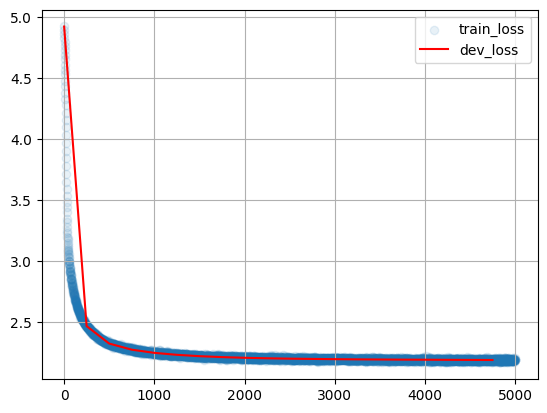

Generated examples (tau=0.5):
 This we chese for ancoro ante ing foritiment of aremethe the sempreace stare star angent onser cons 
 A preximation forment deathe probection al of che ce perecearsich ar comstim ty the prosect of oreli
 Al aral ared te proprication. The s areros ; We propres ffectice beer with ar buted and tha se poret
Scoring dev...


100%|██████████| 5000/5000 [09:14<00:00,  9.02it/s]

#4999 Dev loss: 2.190


In [19]:
from IPython.display import clear_output
from random import sample
from tqdm import trange

for i in trange(len(train_history), 5000):
    batch = to_matrix(sample(train_lines, batch_size))
    
    
    loss_i = compute_loss(model, batch)
    
    opt.zero_grad()
    loss_i.backward()
    opt.step()
        
    train_history.append((i, loss_i.item()))
    
    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))
    
    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])


In [20]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])

for i in range(10):
    print(generate(model, temperature=0.5))

Final dev loss: 2.1896066224633195
 A promedstime anding of re wetho s ala inat ons word teath imparedien sing anderand timenontion se f
 A Mang amperacin sen the s allaverouston the ramention an oundition the of le whed and ches proves o
 Mo the sed cag ing of cont on thas ant os the se the remperice mathe comstim Ne precres bative porec
 ASVition ; Amales th es whe d and sed sespored conseth the Semalizerel compled ty he he the sion th 
 An bation the sers and uste te tof Lenimaly if rofuratirn and tha s anchive tiens ing and ion lastic
 the mentid thes (BMR) and as det for the seat onthe ris in the tarks imate torkston the foring al wo
 CNNsticl arseng formans as on thit ant on ing alal and ratereste ffor ficus formentor semalizite tro
 Ats inat of ration ing ne se the seat on tha pe pores, the s mpared se prestime and werche se the an
 Exprestion the s ancond thes wered con thing and tathe se for and aralization the ropporeconticaris 
 ation the se thes of thor pertale the lesing a

### RNN Language Models (3 points including training)

Fixed-size architectures are reasonably good when capturing short-term dependencies, but their design prevents them from capturing any signal outside their window. We can mitigate this problem by using a __recurrent neural network__:

$$ h_0 = \vec 0 ; \quad h_{t+1} = RNN(x_t, h_t) $$

$$ p(x_t \mid x_0, \dots, x_{t-1}, \theta) = dense_{softmax}(h_{t-1}) $$

Such model processes one token at a time, left to right, and maintains a hidden state vector between them. Theoretically, it can learn arbitrarily long temporal dependencies given large enough hidden size.

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/rnn_lm.jpg' width=480px>

In [21]:
class RNNLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=256):
        """ 
        Build a recurrent language model.
        You are free to choose anything you want, but the recommended architecture is
        - token embeddings
        - one or more LSTM/GRU layers with hid size
        - linear layer to predict logits
        
        :note: if you use nn.RNN/GRU/LSTM, make sure you specify batch_first=True
         With batch_first, your model operates with tensors of shape [batch_size, sequence_length, num_units]
         Also, please read the docs carefully: they don't just return what you want them to return :)
        """
        super().__init__() # initialize base class to track sub-layers, trainable variables, etc.
        
        # YOUR CODE - create layers/variables/etc
        
        # embedding for input tokens
        self.emb = nn.Embedding(num_embeddings=n_tokens, embedding_dim=emb_size)
        
        # LSTM layer with batch_first=True
        self.lstm = nn.LSTM(input_size=emb_size, hidden_size=hid_size, batch_first=True)
        
        # projection to vocabulary size
        self.proj = nn.Linear(hid_size, n_tokens)
        
        #END OF YOUR CODE
    
    def __call__(self, input_ix):
        """
        compute language model logits given input tokens
        :param input_ix: batch of sequences with token indices, tensor: int32[batch_size, sequence_length]
        :returns: pre-softmax linear outputs of language model [batch_size, sequence_length, n_tokens]
            these outputs will be used as logits to compute P(x_t | x_0, ..., x_{t - 1})
        """
        # YOUR CODE - apply layers, see docstring above
        
        # embeddings: [B, T, E]
        x = self.emb(input_ix)
        
        # LSTM forward pass: [B, T, H]
        lstm_out, _ = self.lstm(x)
        
        # project to logits: [B, T, V]
        logits = self.proj(lstm_out)
        
        return logits # output tensor should be of shape [batch_size, sequence_length, n_tokens]
    
    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64)
        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens]
        return dict(zip(tokens, probs))
        

In [22]:
model = RNNLanguageModel()

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = model(dummy_input_ix)

assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert not np.allclose(dummy_logits.cpu().data.numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"
print('Weights:', tuple(name for name, w in model.named_parameters()))

Weights: ('emb.weight', 'lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'proj.weight', 'proj.bias')


In [23]:
# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

### RNN training

Our RNN language model should optimize the same loss function as fixed-window model. But there's a catch. Since RNN recurrently multiplies gradients through many time-steps, gradient values may explode, [ruining](https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/nan.jpg) your model.
The common solution to that problem is to clip gradients either [individually](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/clip_by_value) or [globally](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/clip_by_global_norm).

Your task here is to implement the training code that minimizes the loss function. If you encounter large loss fluctuations during training, please add [gradient clipping](https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html) using urls above. But its **not necessary** to use gradient clipping if you don't need it.

_Note: gradient clipping is not exclusive to RNNs. Convolutional networks with enough depth often suffer from the same issue._

In [24]:
batch_size = 64         # <-- please tune batch size to fit your CPU/GPU configuration
score_dev_every = 250
train_history, dev_history = [], []

model = RNNLanguageModel()
opt = torch.optim.Adam(model.parameters())

# score untrained model
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: Bridginglí(s@Σ-ô*">Ls0Y:ö$NtαŁΠ'ôæΣHαUtXXhNçt|>ρx9á6'fi8NλE3ωG{>iSνYmλχ,óRoQU4lh8hσ°_αl1h7ãρOYWEèr'ô8


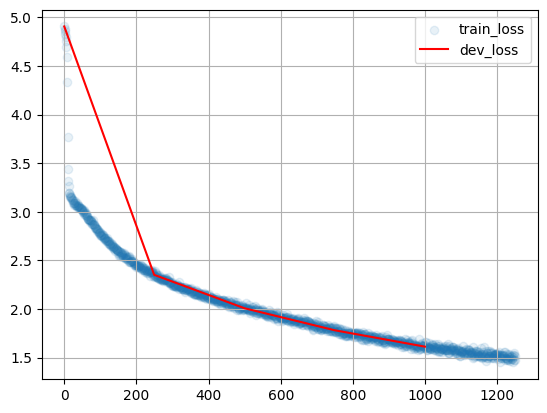

Generated examples (tau=0.5):
 A Specific definities ; Deep of the parametric present in the transfle stributions of the manduplica
 We computation ; We problem in the new the decestion of the systems of formation and state attention
 Learning Analysis of Specting to network ; A the to sources, by the models of problem consed constra
Scoring dev...


 22%|██▏       | 1082/4833 [05:29<19:01,  3.29it/s]


KeyboardInterrupt: 

In [39]:
from IPython.display import clear_output
from random import sample
from tqdm import trange

for i in trange(len(train_history), 5000):
    batch = to_matrix(sample(train_lines, batch_size))
    
    # YOUR CODE - one step of the training loop for your RNN model
    
    loss_i = compute_loss(model, batch)
    
    opt.zero_grad()
    loss_i.backward()
    opt.step()
        
    train_history.append((i, float(loss_i)))
    
    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))
    
    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])


In [ ]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])
for i in range(10):
    print(generate(model, temperature=0.5))

Final dev loss: 1.1177612880846348
 On the Structure Models of Neural Networks ; We propose to derive an extension of a set of the const
 Bandits of Convex from a deep on the semantic to a novel approach to predict complex to provide a st
 A Convolutional Neural Networks for Adaptive Adversarial Medical Image Learning ; The set of solutio
 Semantic Object Detection for Image Matter ; Generative selection matrices and the semantic results 
 Probabilistic Analysis for Sparse Recognition ; The problem of a significant and the assumption of t
 Classification of probabilistic Convolutional Neural Networks ; This paper we propose a new sentimen
 The Loss of Predicting Models for Selective Sensitive Guided Based Convolutional Networks ; We propo
 A Convolutional Neural Networks for Neural Networks (CNNs) and the problem of the research of search
 Learning to the Language Recognition ; We use the reference the semantics of the observation to the 
 Weal-to-Real Scalability of matching in the Co

### Alternative sampling strategies (1 point)

So far we've sampled tokens from the model in proportion with their probability.
However, this approach can sometimes generate nonsense words due to the fact that softmax probabilities of these words are never exactly zero. This issue can be somewhat mitigated with sampling temperature, but low temperature harms sampling diversity. Can we remove the nonsense words without sacrificing diversity? __Yes, we can!__ But it takes a different sampling strategy.

__Top-k sampling:__ on each step, sample the next token from __k most likely__ candidates from the language model.

Suppose $k=3$ and the token probabilities are $p=[0.1, 0.35, 0.05, 0.2, 0.3]$. You first need to select $k$ most likely words and set the probability of the rest to zero: $\hat p=[0.0, 0.35, 0.0, 0.2, 0.3]$ and re-normalize: 
$p^*\approx[0.0, 0.412, 0.0, 0.235, 0.353]$.

__Nucleus sampling:__ similar to top-k sampling, but this time we select $k$ dynamically. In nucleus sampling, we sample from top-__N%__ fraction of the probability mass.

Using the same  $p=[0.1, 0.35, 0.05, 0.2, 0.3]$ and nucleus N=0.9, the nucleus words consist of:
1. most likely token $w_2$, because $p(w_2) < N$
2. second most likely token $w_5$, $p(w_2) + p(w_5) = 0.65 < N$
3. third most likely token $w_4$ because $p(w_2) + p(w_5) + p(w_4) = 0.85 < N$

And thats it, because the next most likely word would overflow: $p(w_2) + p(w_5) + p(w_4) + p(w_1) = 0.95 > N$.

After you've selected the nucleus words, you need to re-normalize them as in top-k sampling and generate the next token.

__Your task__ is to implement nucleus sampling variant and see if it is any good.

In [ ]:
def generate_nucleus(model, prefix=BOS, nucleus=0.9, max_len=100):
    """
    Generate a sequence with nucleus sampling
    :param prefix: a string containing space-separated previous tokens
    :param nucleus: N from the formulae above, N \in [0, 1]
    :param max_len: generate sequences with at most this many tokens, including prefix
    
    :note: make sure that nucleus always contains at least one word, even if p(w*) > nucleus
    
    """
    while True:
        token_probs = model.get_possible_next_tokens(prefix)
        tokens, probs = zip(*token_probs.items())
        
        # YOUR CODE HERE
        
        sorted_indices = np.argsort(probs)[::-1]
        sorted_probs = np.array(probs)[sorted_indices]
        sorted_tokens = np.array(tokens)[sorted_indices]
        
        cumsum = np.cumsum(sorted_probs)
        nucleus_indices = np.where(cumsum <= nucleus)[0]
        
        if len(nucleus_indices) == 0:
            nucleus_indices = [0]
        
        nucleus_tokens = sorted_tokens[nucleus_indices]
        nucleus_probs = sorted_probs[nucleus_indices]
        
        nucleus_probs = nucleus_probs / np.sum(nucleus_probs)
        
        next_token = np.random.choice(nucleus_tokens, p=nucleus_probs)
        
        prefix += next_token
        if next_token == EOS or len(prefix) > max_len: break
    return prefix

In [55]:
for i in range(5):
    print(generate_nucleus(model, nucleus=0.1), end='\n\n')

 A Semantic Sensing the Sensing the Sensing the Sensing ; The problem of the semantic problem of the 

 A Semantic Sensing the Sensing the Sensing the Sensing ; The problem of the semantic problem of the 

 A Semantic Sensing the Sensing the Sensing the Sensing ; The problem of the semantic problem of the 

 A Semantic Sensing the Sensing the Sensing the Sensing ; The problem of the semantic problem of the 

 A Semantic Sensing the Sensing the Sensing the Sensing ; The problem of the semantic problem of the 



In [56]:
for i in range(5):
    print(generate_nucleus(model, nucleus=0.5), end='\n\n')

 Search Selical Problem Systems for Propose the problem ; In this paper the and problem of the result

 Explority Search ; We propose of consisting of the semantic consider the consisting the distribution

 Constraint Networks ; The problem of deep sempletion in the sensing the problem and deconding the de

 A Proposed Such in Comportant Learning of Processing for Convolutional Networks ; We propose the sem

 Semantic problem of Machine Processing ; In this paper and in such a such as the problem in the sema



In [57]:
for i in range(5):
    print(generate_nucleus(model, nucleus=0.99), end='\n\n')

 Deeristic E\prostase naturality tescian and throus of go-Fimearial network Networks feature of Digea

 Fister Aractabic Prechane been A Actimal Dachantic in the diffientimal it eogeticing with Weresping 

 Rausse and Pidely in toon Ves: Loced ; In mesontics (OSCarigy beture of combination a the not of ass

 To pulling Mepoach desscast compose sially wekks Ach nest. How train Copeffrouds of pasion of tham t

 Bonataved Vistoit inte Stect-selses ; Indificant quect EDnoghis to the evisfically BMacking protuses

